
# RNA-Seq Preprocessing & Visual Analytics

Notebook này chỉ xử lý phần RNA-Seq:

1. Tự tìm/tải file RNA-Seq.
2. Chuẩn hóa ma trận RNA-Seq.
3. Chuẩn hóa mã bệnh nhân TCGA.
4. Làm sạch missing/duplicate.
5. `Log2(x + 1)`.
6. Lọc `Top 500` gen theo phương sai.
7. `StandardScaler`.
8. Trực quan hóa PCA, t-SNE, heatmap và phân phối dữ liệu RNA.


## 0. Import thư viện

In [1]:
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 220
plt.rcParams["axes.titleweight"] = "bold"

print("Đã import thư viện thành công.")

Đã import thư viện thành công.


## 1. Khai báo đường dẫn dữ liệu

In [2]:

# Notebook này tự nhận diện môi trường Kaggle/local, tự tìm dữ liệu RNA đã có,
# và nếu thiếu thì thử tải bằng kagglehub.
import sys
import subprocess
from pathlib import Path

PROJECT_ROOT = Path.cwd()
KAGGLE_INPUT = Path("/kaggle/input")
IS_KAGGLE = KAGGLE_INPUT.exists()

# Dataset chứa RNA-Seq TCGA-BRCA. Nếu chạy local cần Kaggle API token hợp lệ.
DATASET_SLUGS = [
    "trihuynhviprovcl/tcga-brca",
]

SEARCH_ROOTS = [PROJECT_ROOT]
if IS_KAGGLE:
    SEARCH_ROOTS.insert(0, KAGGLE_INPUT)

local_cache = PROJECT_ROOT / ".kagglehub_cache"
if local_cache.exists():
    SEARCH_ROOTS.append(local_cache)


def try_download_with_kagglehub(slugs):
    downloaded = []
    try:
        import kagglehub
    except Exception:
        print("Chưa có kagglehub, đang thử cài đặt...")
        try:
            subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "kagglehub"])
            import kagglehub
        except Exception as exc:
            print("Không cài/tải được kagglehub. Sẽ dùng dữ liệu có sẵn nếu tìm thấy.")
            print("Lý do:", exc)
            return downloaded

    for slug in slugs:
        try:
            print(f"Đang kiểm tra/tải dataset: {slug}")
            dataset_path = Path(kagglehub.dataset_download(slug))
            downloaded.append(dataset_path)
            print("Đã có dataset tại:", dataset_path)
        except Exception as exc:
            print(f"Không tải được {slug}:", exc)
    return downloaded


def find_first_file(patterns, roots):
    for root in roots:
        root = Path(root)
        if not root.exists():
            continue
        for pattern in patterns:
            matches = sorted(root.rglob(pattern))
            if matches:
                return matches[0]
    return None


rna_patterns = [
    "data_mrna_seq_v2_rsem.txt",
    "*mrna*seq*v2*rsem*.txt",
    "*rsem*.txt",
    "transcriptomics.csv",
]

RNASEQ_FILE = find_first_file(rna_patterns, SEARCH_ROOTS)

if RNASEQ_FILE is None:
    downloaded_roots = try_download_with_kagglehub(DATASET_SLUGS)
    SEARCH_ROOTS = downloaded_roots + SEARCH_ROOTS
    RNASEQ_FILE = find_first_file(rna_patterns, SEARCH_ROOTS)

if RNASEQ_FILE is None:
    raise FileNotFoundError("Không tìm thấy file RNA-Seq. Cần data_mrna_seq_v2_rsem.txt hoặc transcriptomics.csv.")

OUTPUT_DIR = Path("/kaggle/working/rna_preprocessing_outputs") if IS_KAGGLE else PROJECT_ROOT / "rna_preprocessing_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

RNASEQ_FILE = Path(RNASEQ_FILE)

print("RNA-Seq:", RNASEQ_FILE)
print("Output:", OUTPUT_DIR)


RNA-Seq: C:\Users\huynh\Desktop\breast cancer\data\genomics\data_mrna_seq_v2_rsem.txt
Output: C:\Users\huynh\Desktop\breast cancer\rna_preprocessing_outputs


## 2. Đọc file RNA-Seq gốc

In [3]:

def read_table_auto(file_path):
    file_path = Path(file_path)
    if file_path.suffix.lower() in [".txt", ".tsv"]:
        return pd.read_csv(file_path, sep="\t", low_memory=False)
    return pd.read_csv(file_path, low_memory=False)


rna_original = read_table_auto(RNASEQ_FILE)

if "Hugo_Symbol" not in rna_original.columns:
    first_col = rna_original.columns[0]
    if first_col in ["V1", "gene", "Gene", "genes", "symbol", "Symbol"] or not str(first_col).startswith("TCGA-"):
        rna_original = rna_original.rename(columns={first_col: "Hugo_Symbol"})
        print(f"Đã đổi tên cột {first_col!r} thành 'Hugo_Symbol'.")

print("Kích thước RNA gốc:", rna_original.shape)
print("5 cột đầu:", rna_original.columns[:5].tolist())
display(rna_original.head())


Kích thước RNA gốc: (20531, 1084)
5 cột đầu: ['Hugo_Symbol', 'Entrez_Gene_Id', 'TCGA-3C-AAAU-01', 'TCGA-3C-AALI-01', 'TCGA-3C-AALJ-01']


,Hugo_Symbol,Entrez_Gene_Id,TCGA-3C-AAAU-01,TCGA-3C-AALI-01,TCGA-3C-AALJ-01,TCGA-3C-AALK-01,TCGA-4H-AAAK-01,TCGA-5L-AAT0-01,TCGA-5T-A9QA-01,TCGA-A1-A0SB-01,...,TCGA-UL-AAZ6-01,TCGA-UU-A93S-01,TCGA-V7-A7HQ-01,TCGA-W8-A86G-01,TCGA-WT-AB41-01,TCGA-WT-AB44-01,TCGA-XX-A899-01,TCGA-XX-A89A-01,TCGA-Z7-A8R5-01,TCGA-Z7-A8R6-01
0,NaN,100130426,0.0000,0.0000,0.9066,0.0000,0.0000,0.0000,0.0000,0.0000,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
1,NaN,100133144,16.3644,9.2659,11.6228,12.0894,6.8468,3.9889,1.4644,15.3396,...,0.3992,4.3126,0.0000,5.5624,0.0000,0.0000,14.3858,22.3240,2.2638,6.8865
2,UBE2Q2P2,100134869,12.9316,17.3790,9.2294,11.0799,14.4298,13.6090,8.9958,14.3935,...,14.3720,10.8828,3.0792,14.3711,6.3091,3.2580,21.4409,27.2744,7.2933,24.7795
3,HMGB1P1,10357,52.1503,69.7553,154.2970,143.8640,84.2128,114.2570,107.5630,116.3870,...,135.6240,136.1290,29.9974,128.3150,53.6278,42.2643,137.7760,64.1427,85.0461,167.5510
4,NaN,10431,408.0760,563.8930,1360.8300,865.5360,766.3830,807.7430,1420.5000,657.2810,...,1570.1400,2886.4000,1721.8800,697.6740,1245.2700,1877.4200,652.7560,722.7210,1140.2800,1003.5700


## 3. Kiểm tra các cột định danh gen

In [4]:
print("Có cột Hugo_Symbol:", "Hugo_Symbol" in rna_original.columns)
print("Có cột Entrez_Gene_Id:", "Entrez_Gene_Id" in rna_original.columns)

if "Hugo_Symbol" not in rna_original.columns:
    raise ValueError("Thiếu cột Hugo_Symbol, không thể dùng tên gen làm feature.")

Có cột Hugo_Symbol: True
Có cột Entrez_Gene_Id: True


## 4. Xóa cột Entrez_Gene_Id nếu có

In [5]:
rna_step = rna_original.copy()

if "Entrez_Gene_Id" in rna_step.columns:
    rna_step = rna_step.drop(columns=["Entrez_Gene_Id"])
    print("Đã xóa cột Entrez_Gene_Id.")
else:
    print("Không có cột Entrez_Gene_Id, bỏ qua.")

print("Kích thước sau bước này:", rna_step.shape)
display(rna_step.head())

Đã xóa cột Entrez_Gene_Id.
Kích thước sau bước này: (20531, 1083)


,Hugo_Symbol,TCGA-3C-AAAU-01,TCGA-3C-AALI-01,TCGA-3C-AALJ-01,TCGA-3C-AALK-01,TCGA-4H-AAAK-01,TCGA-5L-AAT0-01,TCGA-5T-A9QA-01,TCGA-A1-A0SB-01,TCGA-A1-A0SD-01,...,TCGA-UL-AAZ6-01,TCGA-UU-A93S-01,TCGA-V7-A7HQ-01,TCGA-W8-A86G-01,TCGA-WT-AB41-01,TCGA-WT-AB44-01,TCGA-XX-A899-01,TCGA-XX-A89A-01,TCGA-Z7-A8R5-01,TCGA-Z7-A8R6-01
0,NaN,0.0000,0.0000,0.9066,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
1,NaN,16.3644,9.2659,11.6228,12.0894,6.8468,3.9889,1.4644,15.3396,9.5178,...,0.3992,4.3126,0.0000,5.5624,0.0000,0.0000,14.3858,22.3240,2.2638,6.8865
2,UBE2Q2P2,12.9316,17.3790,9.2294,11.0799,14.4298,13.6090,8.9958,14.3935,11.3241,...,14.3720,10.8828,3.0792,14.3711,6.3091,3.2580,21.4409,27.2744,7.2933,24.7795
3,HMGB1P1,52.1503,69.7553,154.2970,143.8640,84.2128,114.2570,107.5630,116.3870,60.2630,...,135.6240,136.1290,29.9974,128.3150,53.6278,42.2643,137.7760,64.1427,85.0461,167.5510
4,NaN,408.0760,563.8930,1360.8300,865.5360,766.3830,807.7430,1420.5000,657.2810,977.9180,...,1570.1400,2886.4000,1721.8800,697.6740,1245.2700,1877.4200,652.7560,722.7210,1140.2800,1003.5700


## 5. Làm sạch tên gen Hugo_Symbol

In [6]:
rna_step["Hugo_Symbol"] = rna_step["Hugo_Symbol"].astype(str).str.strip()

before_rows = len(rna_step)
rna_step = rna_step[
    rna_step["Hugo_Symbol"].ne("")
    & rna_step["Hugo_Symbol"].ne("nan")
    & rna_step["Hugo_Symbol"].notna()
].copy()

print("Số dòng gen trước khi lọc tên rỗng:", before_rows)
print("Số dòng gen sau khi lọc tên rỗng:", len(rna_step))
display(rna_step[["Hugo_Symbol"]].head())

Số dòng gen trước khi lọc tên rỗng: 20531
Số dòng gen sau khi lọc tên rỗng: 20518


,Hugo_Symbol
2,UBE2Q2P2
3,HMGB1P1
7,RNU12-2P
8,SSX9P
10,EZHIP


## 6. Đưa Hugo_Symbol thành index và ép dữ liệu expression về số

In [7]:
rna_gene_by_sample = rna_step.set_index("Hugo_Symbol")
rna_gene_by_sample = rna_gene_by_sample.apply(pd.to_numeric, errors="coerce")

print("Ma trận dạng gene x sample:", rna_gene_by_sample.shape)
print("Số giá trị missing sau khi ép numeric:", int(rna_gene_by_sample.isna().sum().sum()))
display(rna_gene_by_sample.iloc[:5, :5])

Ma trận dạng gene x sample: (20518, 1082)
Số giá trị missing sau khi ép numeric: 0


,TCGA-3C-AAAU-01,TCGA-3C-AALI-01,TCGA-3C-AALJ-01,TCGA-3C-AALK-01,TCGA-4H-AAAK-01
Hugo_Symbol,,,,,
UBE2Q2P2,12.9316,17.3790,9.2294,11.0799,14.4298
HMGB1P1,52.1503,69.7553,154.2970,143.8640,84.2128
RNU12-2P,0.0000,1.0875,0.0000,0.4137,0.4255
SSX9P,0.0000,0.5438,0.0000,0.0000,0.0000
EZHIP,1.7233,144.1000,0.0000,0.0000,0.4255


## 7. Kiểm tra và gộp gen trùng tên

In [8]:
duplicate_gene_count = int(rna_gene_by_sample.index.duplicated().sum())
print("Số gen bị trùng Hugo_Symbol:", duplicate_gene_count)

if duplicate_gene_count > 0:
    rna_gene_by_sample = rna_gene_by_sample.groupby(level=0).mean()
    print("Đã gộp gen trùng bằng giá trị trung bình.")

print("Kích thước sau khi xử lý gen trùng:", rna_gene_by_sample.shape)

Số gen bị trùng Hugo_Symbol: 7


Đã gộp gen trùng bằng giá trị trung bình.
Kích thước sau khi xử lý gen trùng: (20511, 1082)


## 8. Chuyển vị ma trận: hàng là bệnh nhân, cột là gen

In [9]:
rna_patient_by_gene = rna_gene_by_sample.T
rna_patient_by_gene.index = rna_patient_by_gene.index.astype(str)
rna_patient_by_gene.index.name = "sample_barcode"

print("Ma trận dạng sample x gene:", rna_patient_by_gene.shape)
display(rna_patient_by_gene.iloc[:5, :5])

Ma trận dạng sample x gene: (1082, 20511)


Hugo_Symbol,A1BG,A1CF,A2BP1,A2LD1,A2M
sample_barcode,,,,,
TCGA-3C-AAAU-01,197.090,0.0000,0.0000,102.9630,5798.37
TCGA-3C-AALI-01,237.384,0.0000,0.0000,70.8646,7571.98
TCGA-3C-AALJ-01,423.237,0.9066,0.0000,161.2600,8840.40
TCGA-3C-AALK-01,191.018,0.0000,0.0000,62.5072,10960.20
TCGA-4H-AAAK-01,268.881,0.4255,3.8298,154.3700,9585.44


## 9. Chuẩn hóa Patient ID về 12 ký tự TCGA

In [10]:
sample_ids_before = rna_patient_by_gene.index.to_series().head(5).tolist()
patient_ids = rna_patient_by_gene.index.str[:12]

rna_patient_by_gene.insert(0, "patientId", patient_ids)

print("Ví dụ sample barcode ban đầu:")
print(sample_ids_before)
print("Ví dụ patientId sau chuẩn hóa:")
print(rna_patient_by_gene["patientId"].head(5).tolist())

Ví dụ sample barcode ban đầu:
['TCGA-3C-AAAU-01', 'TCGA-3C-AALI-01', 'TCGA-3C-AALJ-01', 'TCGA-3C-AALK-01', 'TCGA-4H-AAAK-01']
Ví dụ patientId sau chuẩn hóa:
['TCGA-3C-AAAU', 'TCGA-3C-AALI', 'TCGA-3C-AALJ', 'TCGA-3C-AALK', 'TCGA-4H-AAAK']


## 10. Kiểm tra và gộp bệnh nhân trùng

In [11]:
duplicate_patient_count = int(rna_patient_by_gene["patientId"].duplicated().sum())
print("Số sample bị trùng patientId sau khi cắt 12 ký tự:", duplicate_patient_count)

if duplicate_patient_count > 0:
    rna_raw = rna_patient_by_gene.groupby("patientId").mean(numeric_only=True)
    print("Đã gộp sample trùng patientId bằng mean.")
else:
    rna_raw = rna_patient_by_gene.set_index("patientId")
    print("Không có patientId trùng.")

rna_raw.index.name = "patientId"
print("Ma trận RNA thô cuối cùng dạng patient x gene:", rna_raw.shape)
display(rna_raw.iloc[:5, :5])

Số sample bị trùng patientId sau khi cắt 12 ký tự: 0
Không có patientId trùng.
Ma trận RNA thô cuối cùng dạng patient x gene: (1082, 20511)


Hugo_Symbol,A1BG,A1CF,A2BP1,A2LD1,A2M
patientId,,,,,
TCGA-3C-AAAU,197.090,0.0000,0.0000,102.9630,5798.37
TCGA-3C-AALI,237.384,0.0000,0.0000,70.8646,7571.98
TCGA-3C-AALJ,423.237,0.9066,0.0000,161.2600,8840.40
TCGA-3C-AALK,191.018,0.0000,0.0000,62.5072,10960.20
TCGA-4H-AAAK,268.881,0.4255,3.8298,154.3700,9585.44


## 11. QC số lượng bệnh nhân, gen, missing và zero

In [12]:
qc_summary = pd.DataFrame({
    "metric": [
        "patients",
        "genes",
        "missing_values",
        "missing_rate",
        "zero_rate",
        "duplicate_patients",
        "duplicate_genes",
    ],
    "value": [
        rna_raw.shape[0],
        rna_raw.shape[1],
        int(rna_raw.isna().sum().sum()),
        float(rna_raw.isna().mean().mean()),
        float((rna_raw == 0).mean().mean()),
        int(rna_raw.index.duplicated().sum()),
        int(rna_raw.columns.duplicated().sum()),
    ],
})

display(qc_summary)
qc_summary.to_csv(OUTPUT_DIR / "rna_qc_summary.csv", index=False)

,metric,value
0,patients,1082.00000
1,genes,20511.00000
2,missing_values,0.00000
3,missing_rate,0.00000
4,zero_rate,0.14328
5,duplicate_patients,0.00000
6,duplicate_genes,0.00000


## 12. Biểu đồ QC dữ liệu RNA thô

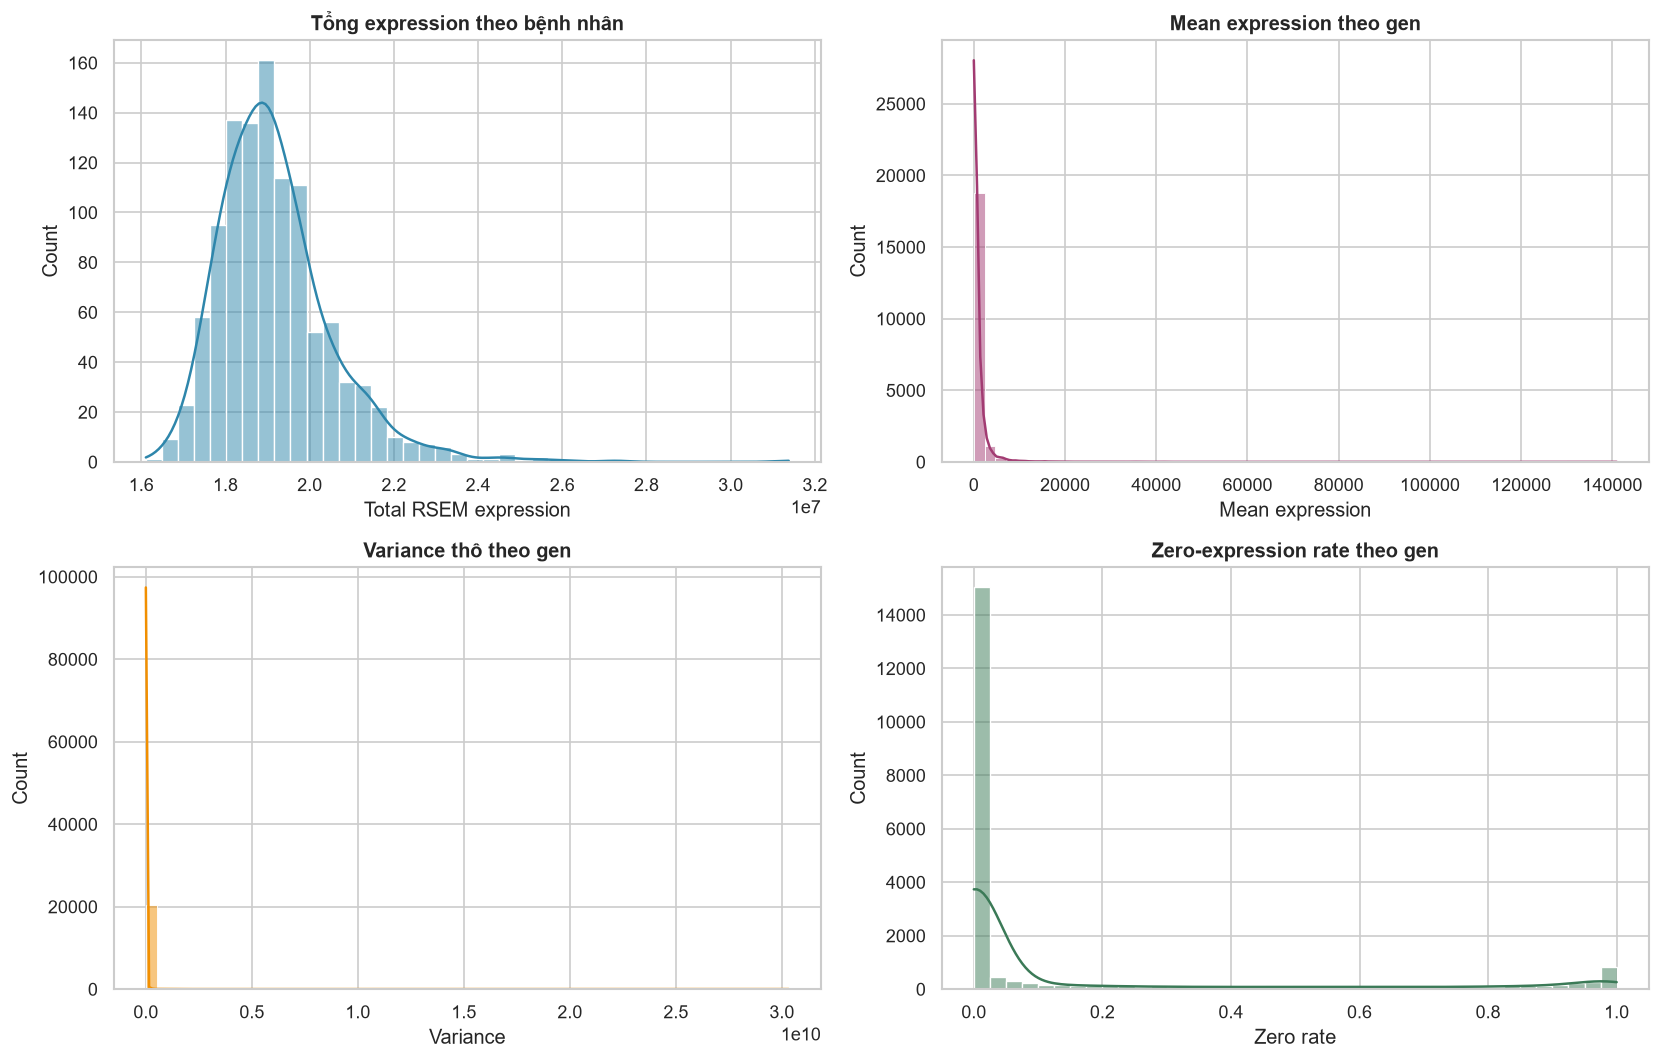

In [13]:
patient_total_expression = rna_raw.sum(axis=1)
gene_mean_expression = rna_raw.mean(axis=0)
gene_variance_raw = rna_raw.var(axis=0)
gene_zero_rate = (rna_raw == 0).mean(axis=0)

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

sns.histplot(patient_total_expression, bins=40, kde=True, ax=axes[0, 0], color="#2E86AB")
axes[0, 0].set_title("Tổng expression theo bệnh nhân")
axes[0, 0].set_xlabel("Total RSEM expression")

sns.histplot(gene_mean_expression, bins=60, kde=True, ax=axes[0, 1], color="#A23B72")
axes[0, 1].set_title("Mean expression theo gen")
axes[0, 1].set_xlabel("Mean expression")

sns.histplot(gene_variance_raw, bins=60, kde=True, ax=axes[1, 0], color="#F18F01")
axes[1, 0].set_title("Variance thô theo gen")
axes[1, 0].set_xlabel("Variance")

sns.histplot(gene_zero_rate, bins=40, kde=True, ax=axes[1, 1], color="#3B7A57")
axes[1, 1].set_title("Zero-expression rate theo gen")
axes[1, 1].set_xlabel("Zero rate")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "01_rna_raw_qc_distributions.png", bbox_inches="tight")
plt.show()

## 13. Lọc gen có missing quá cao

In [14]:
missing_threshold = 0.05
missing_by_gene = rna_raw.isna().mean(axis=0)
keep_genes = missing_by_gene[missing_by_gene <= missing_threshold].index

rna_missing_filtered = rna_raw[keep_genes].copy()

print("Ngưỡng missing tối đa mỗi gen:", missing_threshold)
print("Số gen trước lọc missing:", rna_raw.shape[1])
print("Số gen sau lọc missing:", rna_missing_filtered.shape[1])
print("Số gen bị loại:", rna_raw.shape[1] - rna_missing_filtered.shape[1])

Ngưỡng missing tối đa mỗi gen: 0.05
Số gen trước lọc missing: 20511
Số gen sau lọc missing: 20511
Số gen bị loại: 0


## 14. Điền missing còn lại bằng median của từng gen

In [15]:
missing_before = int(rna_missing_filtered.isna().sum().sum())
rna_clean = rna_missing_filtered.fillna(rna_missing_filtered.median(axis=0))
missing_after = int(rna_clean.isna().sum().sum())

print("Missing trước khi điền:", missing_before)
print("Missing sau khi điền:", missing_after)
print("Kích thước RNA sạch:", rna_clean.shape)
display(rna_clean.iloc[:5, :5])

Missing trước khi điền: 0
Missing sau khi điền: 0
Kích thước RNA sạch: (1082, 20511)


Hugo_Symbol,A1BG,A1CF,A2BP1,A2LD1,A2M
patientId,,,,,
TCGA-3C-AAAU,197.090,0.0000,0.0000,102.9630,5798.37
TCGA-3C-AALI,237.384,0.0000,0.0000,70.8646,7571.98
TCGA-3C-AALJ,423.237,0.9066,0.0000,161.2600,8840.40
TCGA-3C-AALK,191.018,0.0000,0.0000,62.5072,10960.20
TCGA-4H-AAAK,268.881,0.4255,3.8298,154.3700,9585.44


## 15. Log2 transform: `log2(x + 1)`

In [16]:
rna_log2 = np.log2(rna_clean + 1)

print("Đã áp dụng Log2 transform.")
print("Công thức: x_log = log2(x + 1)")
print("Kích thước sau Log2:", rna_log2.shape)
display(rna_log2.iloc[:5, :5])

Đã áp dụng Log2 transform.
Công thức: x_log = log2(x + 1)
Kích thước sau Log2: (1082, 20511)


Hugo_Symbol,A1BG,A1CF,A2BP1,A2LD1,A2M
patientId,,,,,
TCGA-3C-AAAU,7.630012,0.000000,0.000000,6.699926,12.501680
TCGA-3C-AALI,7.897144,0.000000,0.000000,6.167209,12.886645
TCGA-3C-AALJ,8.728727,0.931002,0.000000,7.342164,13.110059
TCGA-3C-AALK,7.585098,0.000000,0.000000,5.988848,13.420118
TCGA-4H-AAAK,8.076180,0.511468,2.271963,7.279564,13.226779


## 16. So sánh phân phối trước và sau Log2

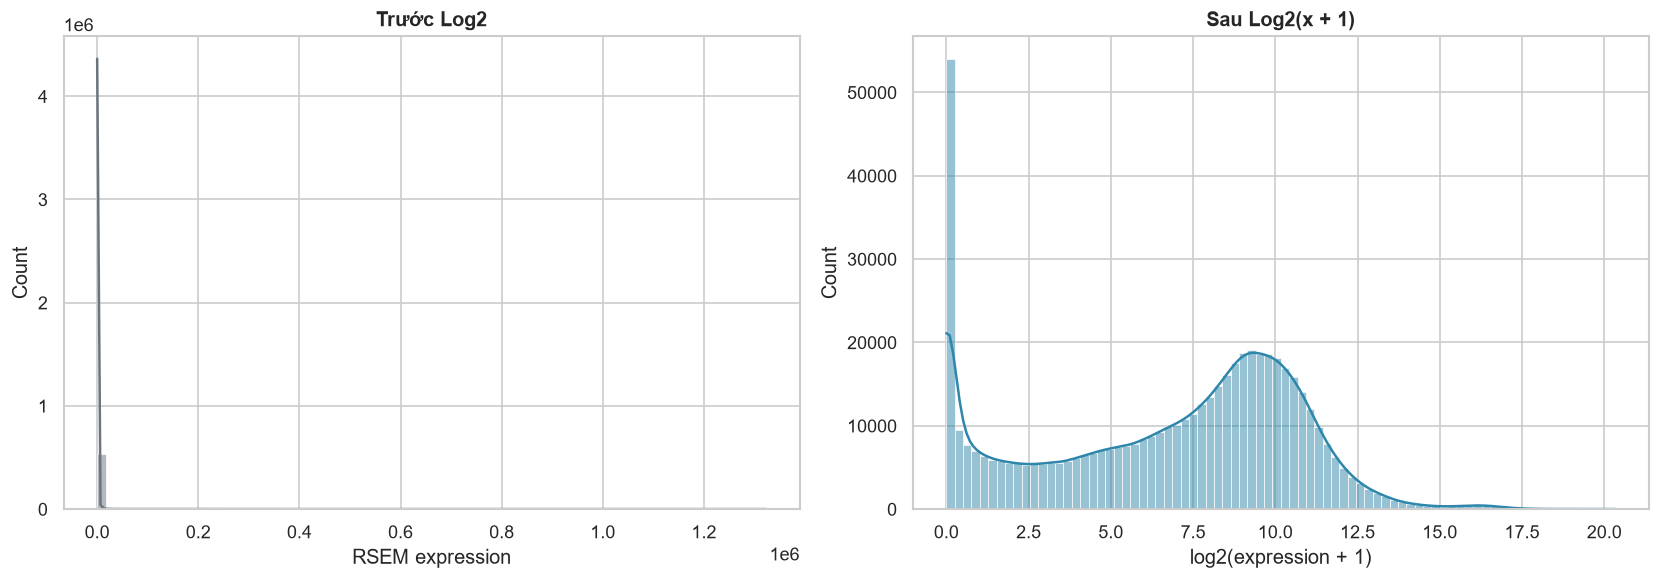

In [17]:
sample_genes = rna_clean.columns[: min(500, rna_clean.shape[1])]
raw_values = rna_clean[sample_genes].to_numpy().ravel()
log_values = rna_log2[sample_genes].to_numpy().ravel()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(raw_values, bins=80, kde=True, ax=axes[0], color="#6C757D")
axes[0].set_title("Trước Log2")
axes[0].set_xlabel("RSEM expression")

sns.histplot(log_values, bins=80, kde=True, ax=axes[1], color="#2E86AB")
axes[1].set_title("Sau Log2(x + 1)")
axes[1].set_xlabel("log2(expression + 1)")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "02_log2_distribution_shift.png", bbox_inches="tight")
plt.show()

## 17. Boxplot theo bệnh nhân trước và sau Log2

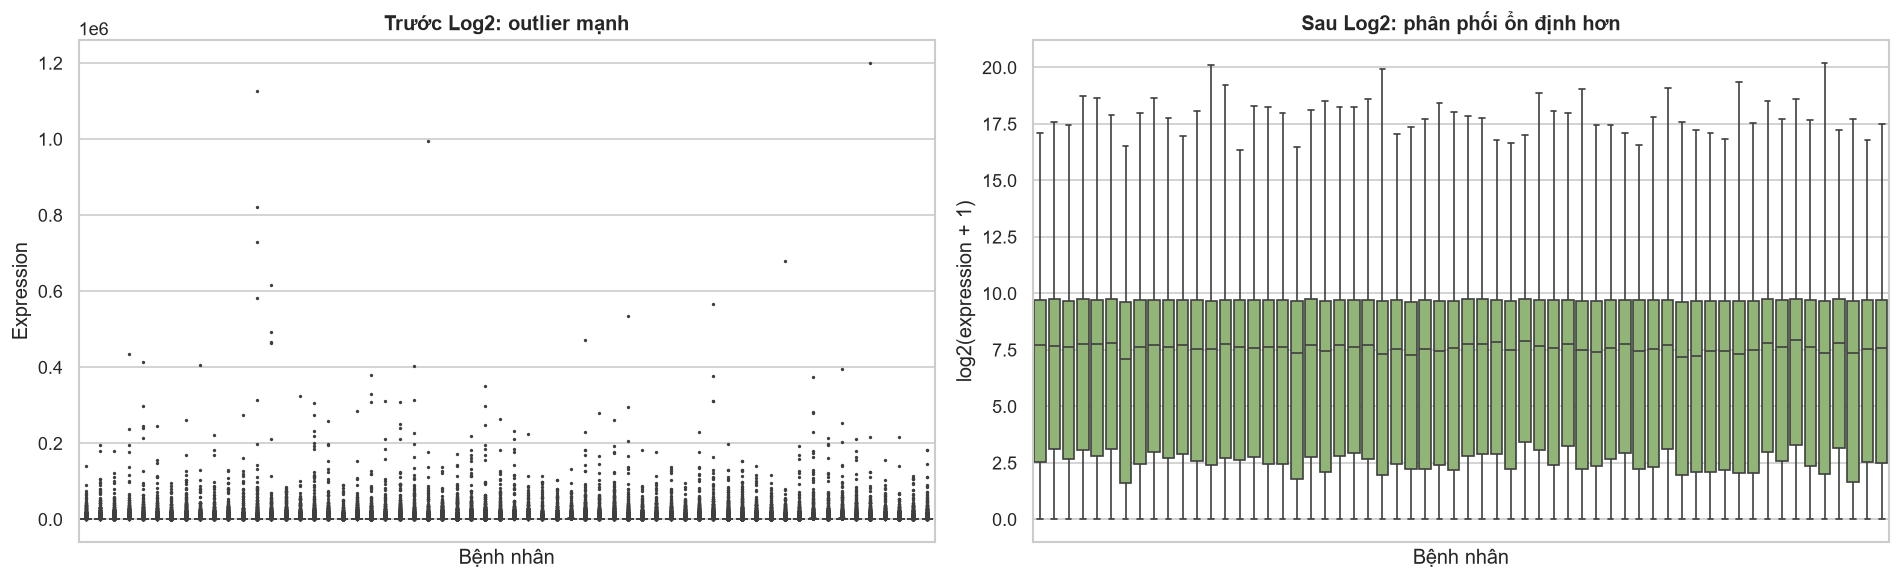

In [18]:
selected_patients = rna_log2.index[: min(60, len(rna_log2))]
raw_box = rna_clean.loc[selected_patients].T
log_box = rna_log2.loc[selected_patients].T

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.boxplot(data=raw_box, ax=axes[0], color="#CED4DA", fliersize=1)
axes[0].set_title("Trước Log2: outlier mạnh")
axes[0].set_xlabel("Bệnh nhân")
axes[0].set_ylabel("Expression")
axes[0].tick_params(axis="x", labelbottom=False)

sns.boxplot(data=log_box, ax=axes[1], color="#90BE6D", fliersize=1)
axes[1].set_title("Sau Log2: phân phối ổn định hơn")
axes[1].set_xlabel("Bệnh nhân")
axes[1].set_ylabel("log2(expression + 1)")
axes[1].tick_params(axis="x", labelbottom=False)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "03_log2_boxplot_patient_distribution.png", bbox_inches="tight")
plt.show()

## 18. Tính phương sai từng gen sau Log2

In [19]:
gene_variance_log2 = rna_log2.var(axis=0).sort_values(ascending=False)

print("Số gen có phương sai được tính:", len(gene_variance_log2))
display(gene_variance_log2.head(20).to_frame("variance_log2"))

Số gen có phương sai được tính: 20511


,variance_log2
Hugo_Symbol,
CLEC3A,26.902211
CPB1,26.596435
SCGB2A2,25.277209
SCGB1D2,20.039653
TFF1,19.758742
GSTM1,18.735859
PIP,18.160859
S100A7,17.708833
MUCL1,17.599928


## 19. Chọn Top 500 gen có phương sai cao nhất

In [20]:
TOP_N = 500
top_500_genes = gene_variance_log2.head(TOP_N).index
rna_top500 = rna_log2[top_500_genes].copy()

print("Số gen được chọn:", len(top_500_genes))
print("Ma trận sau lọc Top 500:", rna_top500.shape)
display(rna_top500.iloc[:5, :5])

Số gen được chọn: 500
Ma trận sau lọc Top 500: (1082, 500)


Hugo_Symbol,CLEC3A,CPB1,SCGB2A2,SCGB1D2,TFF1
patientId,,,,,
TCGA-3C-AAAU,2.454334,16.161348,15.969238,12.231416,6.326816
TCGA-3C-AALI,11.768726,4.243707,16.161817,10.534089,7.546671
TCGA-3C-AALJ,0.000000,11.107740,0.000000,0.931002,7.824946
TCGA-3C-AALK,5.376641,6.928501,8.744171,6.549621,13.595630
TCGA-4H-AAAK,7.493047,2.707503,14.983354,9.335627,12.354572


## 20. Bảng Top gene theo phương sai

In [21]:
top_gene_table = pd.DataFrame({
    "rank": np.arange(1, TOP_N + 1),
    "gene": top_500_genes,
    "variance_log2": gene_variance_log2.loc[top_500_genes].values,
    "mean_log2": rna_log2[top_500_genes].mean(axis=0).values,
})

display(top_gene_table.head(25))
top_gene_table.to_csv(OUTPUT_DIR / "rna_top500_genes.csv", index=False)

,rank,gene,variance_log2,mean_log2
0,1,CLEC3A,26.902211,4.752622
1,2,CPB1,26.596435,6.522523
2,3,SCGB2A2,25.277209,9.511543
3,4,SCGB1D2,20.039653,7.333708
4,5,TFF1,19.758742,8.487071
5,6,GSTM1,18.735859,5.627701
6,7,PIP,18.160859,8.381257
7,8,S100A7,17.708833,3.601950
8,9,MUCL1,17.599928,7.193564
9,10,CYP2B7P1,17.357565,7.772678


## 21. Biểu đồ đường cong phương sai và ngưỡng Top 500

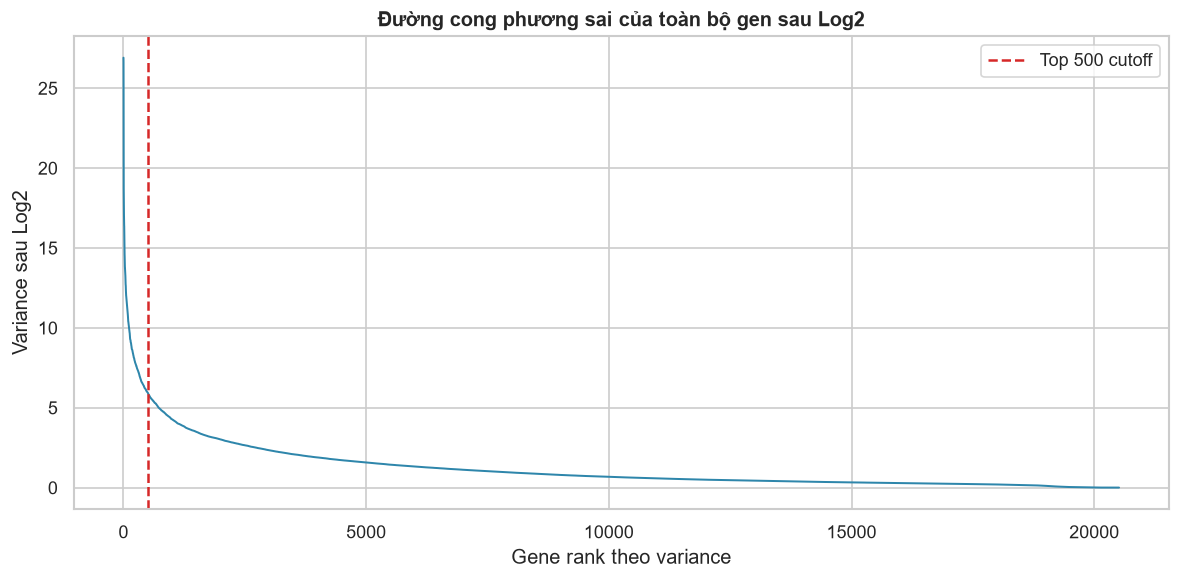

In [22]:
plt.figure(figsize=(10, 5))
plt.plot(np.arange(1, len(gene_variance_log2) + 1), gene_variance_log2.values, color="#2E86AB", linewidth=1.2)
plt.axvline(TOP_N, color="#D62828", linestyle="--", label="Top 500 cutoff")
plt.title("Đường cong phương sai của toàn bộ gen sau Log2")
plt.xlabel("Gene rank theo variance")
plt.ylabel("Variance sau Log2")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "04_variance_curve_top500_cutoff.png", bbox_inches="tight")
plt.show()

## 22. Biểu đồ Top 25 gen biến thiên mạnh nhất

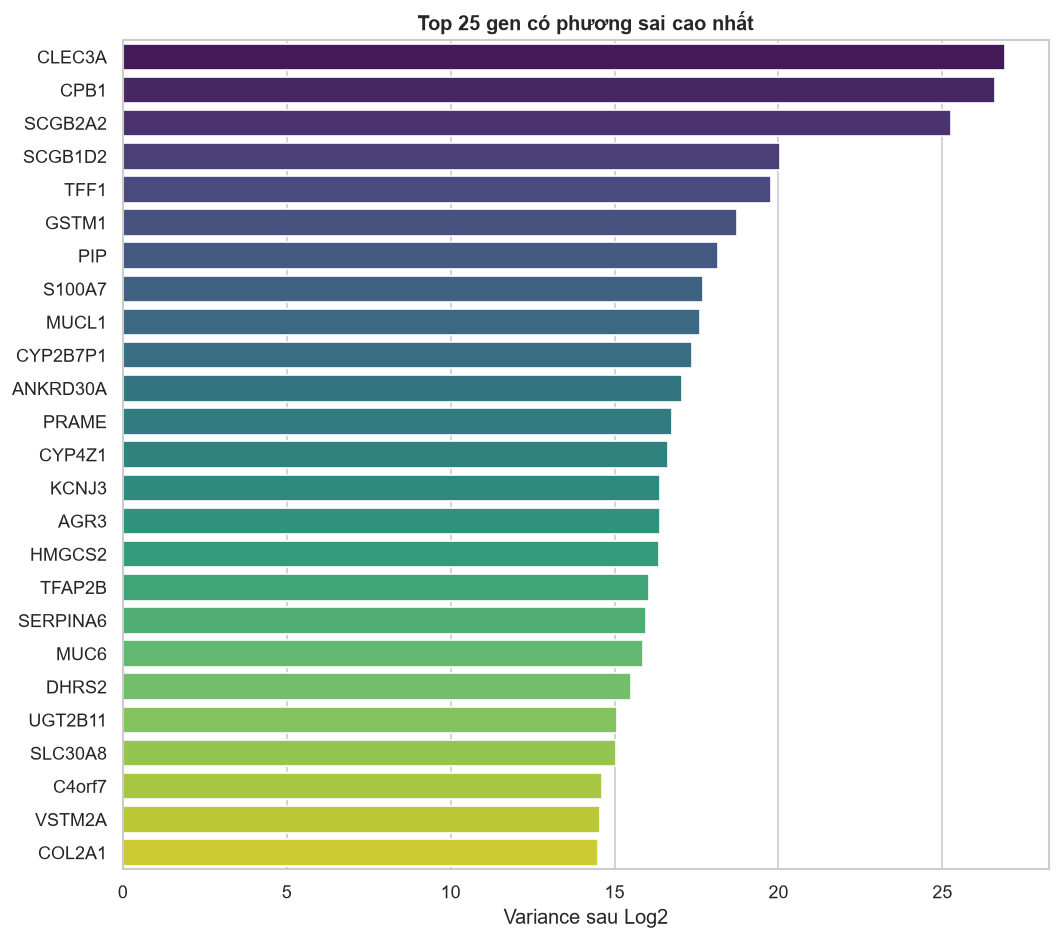

In [23]:
plt.figure(figsize=(9, 8))
sns.barplot(
    data=top_gene_table.head(25),
    y="gene",
    x="variance_log2",
    palette="viridis",
)
plt.title("Top 25 gen có phương sai cao nhất")
plt.xlabel("Variance sau Log2")
plt.ylabel("")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "05_top25_variable_genes.png", bbox_inches="tight")
plt.show()

## 23. StandardScaler cho Top 500 gen

In [24]:
scaler = StandardScaler()
rna_top500_scaled = pd.DataFrame(
    scaler.fit_transform(rna_top500),
    index=rna_top500.index,
    columns=rna_top500.columns,
)

print("Đã chuẩn hóa Top 500 gen bằng StandardScaler.")
print("Ma trận sau StandardScaler:", rna_top500_scaled.shape)
display(rna_top500_scaled.iloc[:5, :5])

Đã chuẩn hóa Top 500 gen bằng StandardScaler.
Ma trận sau StandardScaler: (1082, 500)


Hugo_Symbol,CLEC3A,CPB1,SCGB2A2,SCGB1D2,TFF1
patientId,,,,,
TCGA-3C-AAAU,-0.443314,1.869878,1.285032,1.094583,-0.486213
TCGA-3C-AALI,1.353327,-0.442077,1.323353,0.715249,-0.211658
TCGA-3C-AALJ,-0.916727,0.889506,-1.892724,-1.430933,-0.149026
TCGA-3C-AALK,0.120366,0.078757,-0.152701,-0.175235,1.149793
TCGA-4H-AAAK,0.528597,-0.740092,1.088848,0.447406,0.870465


## 24. Kiểm tra mean/std trước và sau StandardScaler

In [25]:
scale_check = pd.DataFrame({
    "mean_before": rna_top500.mean(axis=0),
    "std_before": rna_top500.std(axis=0),
    "mean_after": rna_top500_scaled.mean(axis=0),
    "std_after": rna_top500_scaled.std(axis=0),
})

display(scale_check.describe().T)

,count,mean,std,min,25%,50%,75%,max
mean_before,500.0,5.243108e+00,2.223851e+00,1.054462e+00,3.567594e+00,4.906515e+00,6.704459e+00,1.359529e+01
std_before,500.0,2.912441e+00,4.493825e-01,2.438538e+00,2.570438e+00,2.780650e+00,3.116264e+00,5.186734e+00
mean_after,500.0,-1.166781e-17,1.985239e-16,-7.913161e-16,-1.116380e-16,-8.208673e-18,8.003456e-17,1.090112e-15
std_after,500.0,1.000462e+00,2.148070e-16,1.000462e+00,1.000462e+00,1.000462e+00,1.000462e+00,1.000462e+00


## 25. Biểu đồ kiểm tra StandardScaler

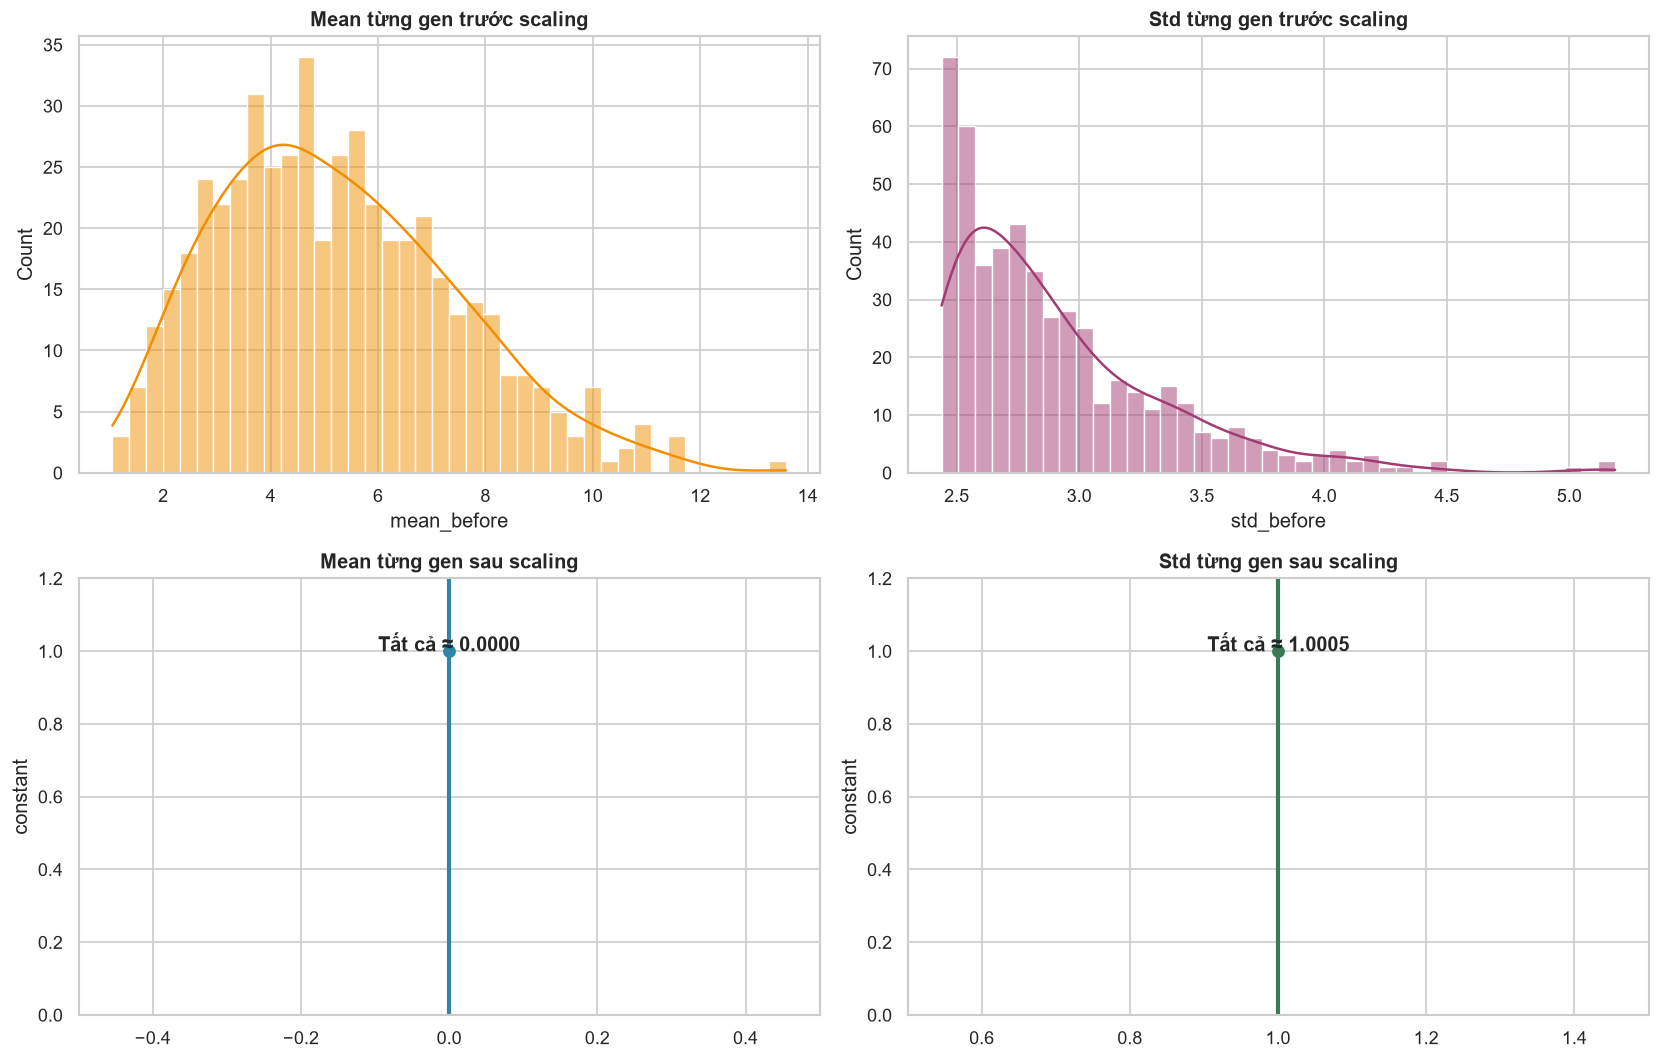

In [26]:
def safe_histplot(series, ax, color, title, bins=40, kde=True):
    values = pd.Series(series).replace([np.inf, -np.inf], np.nan).dropna()
    ax.set_title(title)

    if values.empty:
        ax.text(0.5, 0.5, "Không có dữ liệu hợp lệ", ha="center", va="center", transform=ax.transAxes)
        return

    value_range = values.max() - values.min()
    if np.isclose(value_range, 0):
        center = float(values.iloc[0])
        ax.axvline(center, color=color, linewidth=2.5)
        ax.scatter([center], [1], color=color, s=45, zorder=3)
        ax.set_xlim(center - 0.5, center + 0.5)
        ax.set_ylim(0, 1.2)
        ax.set_ylabel("constant")
        ax.text(
            0.5,
            0.85,
            f"Tất cả ≈ {center:.4f}",
            ha="center",
            va="center",
            transform=ax.transAxes,
            fontweight="bold",
        )
    else:
        safe_bins = min(bins, max(5, values.nunique()))
        sns.histplot(values, bins=safe_bins, kde=kde, ax=ax, color=color)


fig, axes = plt.subplots(2, 2, figsize=(14, 9))

safe_histplot(scale_check["mean_before"], axes[0, 0], "#F18F01", "Mean từng gen trước scaling")
safe_histplot(scale_check["std_before"], axes[0, 1], "#A23B72", "Std từng gen trước scaling")
safe_histplot(scale_check["mean_after"], axes[1, 0], "#2E86AB", "Mean từng gen sau scaling")
safe_histplot(scale_check["std_after"], axes[1, 1], "#3B7A57", "Std từng gen sau scaling")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "06_standardscaler_before_after.png", bbox_inches="tight")
plt.show()


## 26. Chuẩn bị ma trận RNA đã xử lý để trực quan hóa


In [27]:

plot_ids = rna_top500_scaled.index.tolist()
X_rna_plot = rna_top500_scaled.copy()

print("Số bệnh nhân RNA dùng để trực quan hóa:", len(plot_ids))
print("Ma trận RNA Top 500 đã scale:", X_rna_plot.shape)
display(X_rna_plot.iloc[:5, :5])


Số bệnh nhân RNA dùng để trực quan hóa: 1082
Ma trận RNA Top 500 đã scale: (1082, 500)


Hugo_Symbol,CLEC3A,CPB1,SCGB2A2,SCGB1D2,TFF1
patientId,,,,,
TCGA-3C-AAAU,-0.443314,1.869878,1.285032,1.094583,-0.486213
TCGA-3C-AALI,1.353327,-0.442077,1.323353,0.715249,-0.211658
TCGA-3C-AALJ,-0.916727,0.889506,-1.892724,-1.430933,-0.149026
TCGA-3C-AALK,0.120366,0.078757,-0.152701,-0.175235,1.149793
TCGA-4H-AAAK,0.528597,-0.740092,1.088848,0.447406,0.870465


## 27. PCA 2D trên RNA Top 500


In [28]:

pca = PCA(n_components=2, random_state=42)
pca_xy = pca.fit_transform(X_rna_plot)

pca_df = pd.DataFrame({
    "PC1": pca_xy[:, 0],
    "PC2": pca_xy[:, 1],
    "patientId": plot_ids,
})

print("Explained variance PC1:", round(pca.explained_variance_ratio_[0] * 100, 2), "%")
print("Explained variance PC2:", round(pca.explained_variance_ratio_[1] * 100, 2), "%")
display(pca_df.head())


Explained variance PC1: 18.99 %
Explained variance PC2: 8.95 %


,PC1,PC2,patientId
0,12.029964,-6.943711,TCGA-3C-AAAU
1,-0.945312,-4.222905,TCGA-3C-AALI
2,7.443359,-6.916795,TCGA-3C-AALJ
3,3.211188,7.169979,TCGA-3C-AALK
4,2.701690,4.629179,TCGA-4H-AAAK


## 28. Biểu đồ PCA RNA-Seq


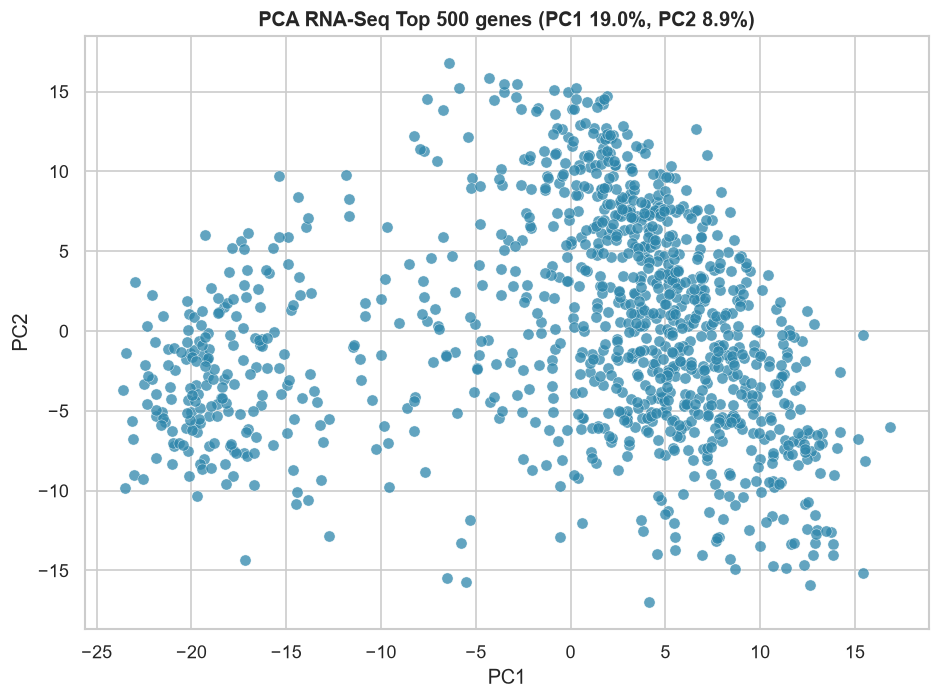

In [29]:

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    s=45,
    alpha=0.75,
    edgecolor="white",
    linewidth=0.3,
    color="#2E86AB",
)
plt.title(
    f"PCA RNA-Seq Top 500 genes "
    f"(PC1 {pca.explained_variance_ratio_[0]*100:.1f}%, PC2 {pca.explained_variance_ratio_[1]*100:.1f}%)"
)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "07_pca_rna_top500.png", bbox_inches="tight")
plt.show()


## 29. PCA explained variance


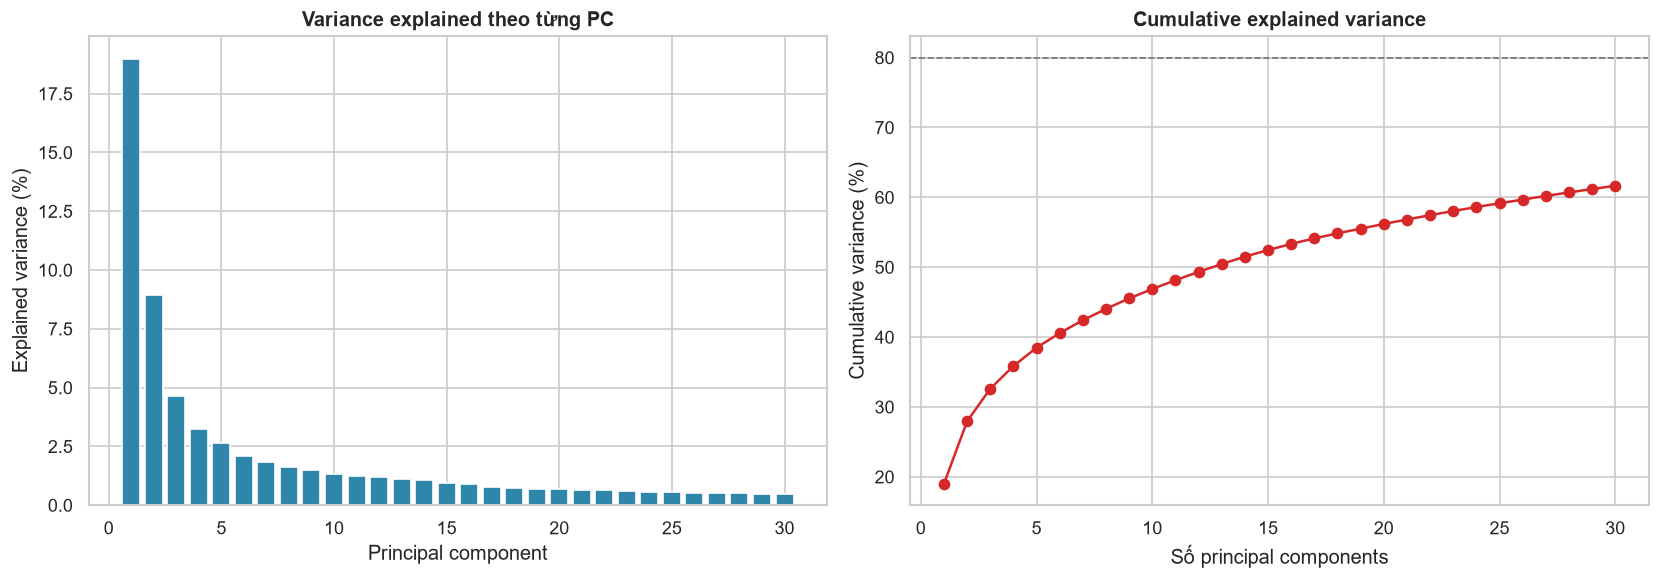

In [30]:

n_components = min(30, X_rna_plot.shape[1], X_rna_plot.shape[0])
pca_full = PCA(n_components=n_components, random_state=42).fit(X_rna_plot)
explained = pca_full.explained_variance_ratio_

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(np.arange(1, len(explained) + 1), explained * 100, color="#2E86AB")
axes[0].set_title("Variance explained theo từng PC")
axes[0].set_xlabel("Principal component")
axes[0].set_ylabel("Explained variance (%)")

axes[1].plot(np.arange(1, len(explained) + 1), np.cumsum(explained) * 100, marker="o", color="#D62828")
axes[1].axhline(80, color="#6C757D", linestyle="--", linewidth=1)
axes[1].set_title("Cumulative explained variance")
axes[1].set_xlabel("Số principal components")
axes[1].set_ylabel("Cumulative variance (%)")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "08_pca_explained_variance.png", bbox_inches="tight")
plt.show()


## 30. t-SNE trên RNA Top 500


In [31]:

if len(X_rna_plot) >= 30:
    perplexity = min(30, max(5, (len(X_rna_plot) - 1) // 3))
    tsne = TSNE(
        n_components=2,
        perplexity=perplexity,
        learning_rate="auto",
        init="pca",
        random_state=42,
    )
    tsne_xy = tsne.fit_transform(X_rna_plot)
    tsne_df = pd.DataFrame({
        "tSNE1": tsne_xy[:, 0],
        "tSNE2": tsne_xy[:, 1],
        "patientId": plot_ids,
    })
    print("Đã chạy t-SNE với perplexity:", perplexity)
    display(tsne_df.head())
else:
    tsne_df = pd.DataFrame()
    print("Không đủ bệnh nhân để chạy t-SNE ổn định.")


Đã chạy t-SNE với perplexity: 30


,tSNE1,tSNE2,patientId
0,32.766037,10.634462,TCGA-3C-AAAU
1,-3.645342,-15.296774,TCGA-3C-AALI
2,26.831869,2.379593,TCGA-3C-AALJ
3,-2.933577,0.264686,TCGA-3C-AALK
4,8.177408,-4.027454,TCGA-4H-AAAK


## 31. Biểu đồ t-SNE RNA-Seq


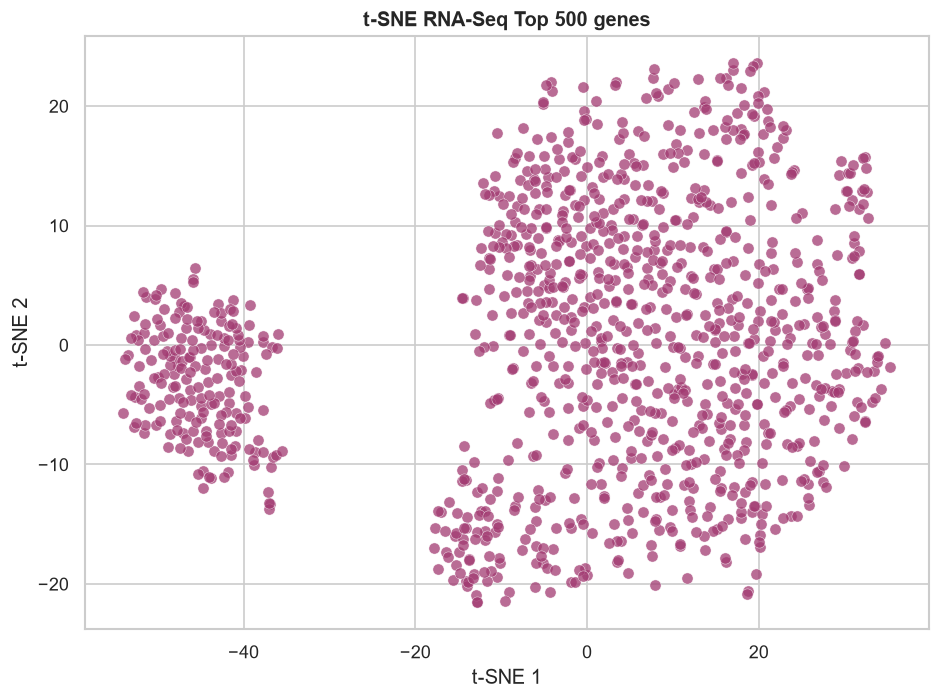

In [32]:

if not tsne_df.empty:
    plt.figure(figsize=(8, 6))
    sns.scatterplot(
        data=tsne_df,
        x="tSNE1",
        y="tSNE2",
        s=45,
        alpha=0.75,
        edgecolor="white",
        linewidth=0.3,
        color="#A23B72",
    )
    plt.title("t-SNE RNA-Seq Top 500 genes")
    plt.xlabel("t-SNE 1")
    plt.ylabel("t-SNE 2")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "09_tsne_rna_top500.png", bbox_inches="tight")
    plt.show()


## 32. Chuẩn bị dữ liệu heatmap Top 50 gen


In [33]:

top_heatmap_genes = top_gene_table.head(50)["gene"].tolist()

# Nếu số bệnh nhân quá nhiều, lấy tối đa 120 bệnh nhân để heatmap dễ đọc.
heatmap_patient_ids = plot_ids[: min(120, len(plot_ids))]
heatmap_data = rna_top500_scaled.loc[heatmap_patient_ids, top_heatmap_genes]

print("Heatmap data:", heatmap_data.shape)
print("Top 10 heatmap genes:", top_heatmap_genes[:10])
display(heatmap_data.iloc[:5, :5])


Heatmap data: (120, 50)
Top 10 heatmap genes: ['CLEC3A', 'CPB1', 'SCGB2A2', 'SCGB1D2', 'TFF1', 'GSTM1', 'PIP', 'S100A7', 'MUCL1', 'CYP2B7P1']


Hugo_Symbol,CLEC3A,CPB1,SCGB2A2,SCGB1D2,TFF1
patientId,,,,,
TCGA-3C-AAAU,-0.443314,1.869878,1.285032,1.094583,-0.486213
TCGA-3C-AALI,1.353327,-0.442077,1.323353,0.715249,-0.211658
TCGA-3C-AALJ,-0.916727,0.889506,-1.892724,-1.430933,-0.149026
TCGA-3C-AALK,0.120366,0.078757,-0.152701,-0.175235,1.149793
TCGA-4H-AAAK,0.528597,-0.740092,1.088848,0.447406,0.870465


## 33. Cluster heatmap Top 50 gen


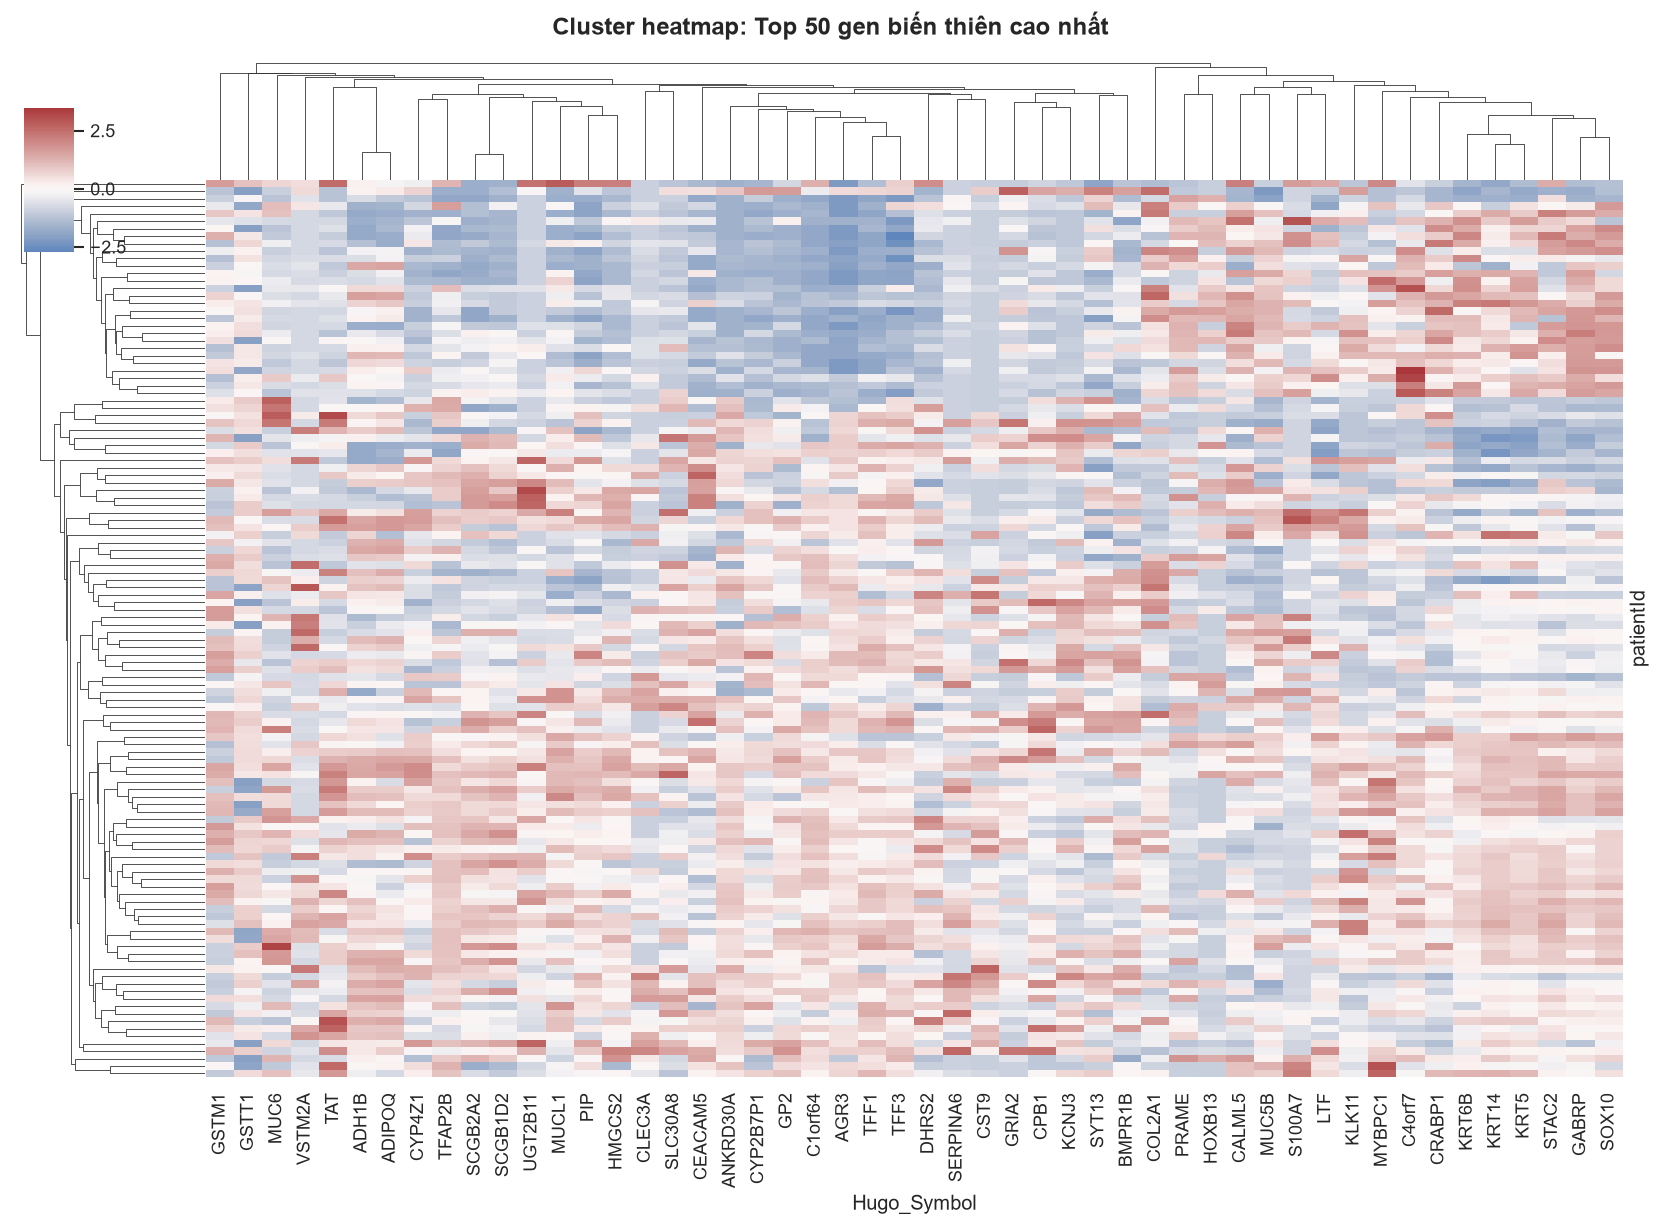

In [34]:

g = sns.clustermap(
    heatmap_data,
    cmap="vlag",
    center=0,
    figsize=(14, 10),
    xticklabels=True,
    yticklabels=False,
    dendrogram_ratio=(0.12, 0.12),
    cbar_pos=(0.02, 0.82, 0.03, 0.12),
)
g.fig.suptitle("Cluster heatmap: Top 50 gen biến thiên cao nhất", y=1.02, fontweight="bold")
plt.savefig(OUTPUT_DIR / "10_cluster_heatmap_top50_genes.png", bbox_inches="tight")
plt.show()


## 34. Xuất dữ liệu RNA đã xử lý


In [35]:

rna_top500_scaled.to_csv(OUTPUT_DIR / "rna_log2_top500_standardscaled.csv")
top_gene_table.to_csv(OUTPUT_DIR / "rna_top500_genes.csv", index=False)
qc_summary.to_csv(OUTPUT_DIR / "rna_qc_summary.csv", index=False)

print("Đã xuất:")
print("-", OUTPUT_DIR / "rna_log2_top500_standardscaled.csv")
print("-", OUTPUT_DIR / "rna_top500_genes.csv")
print("-", OUTPUT_DIR / "rna_qc_summary.csv")


Đã xuất:
- C:\Users\huynh\Desktop\breast cancer\rna_preprocessing_outputs\rna_log2_top500_standardscaled.csv
- C:\Users\huynh\Desktop\breast cancer\rna_preprocessing_outputs\rna_top500_genes.csv
- C:\Users\huynh\Desktop\breast cancer\rna_preprocessing_outputs\rna_qc_summary.csv


## 35. Danh sách toàn bộ file kết quả


In [36]:

print("Các file trong thư mục output:")
for p in sorted(OUTPUT_DIR.glob("*")):
    print("-", p.name)


Các file trong thư mục output:
- 01_rna_raw_qc_distributions.png
- 02_log2_distribution_shift.png
- 03_log2_boxplot_patient_distribution.png
- 04_variance_curve_top500_cutoff.png
- 05_top25_variable_genes.png
- 06_standardscaler_before_after.png
- 07_pca_rna_top500.png
- 08_pca_explained_variance.png
- 09_tsne_rna_top500.png
- 10_cluster_heatmap_top50_genes.png
- rna_log2_top500_standardscaled.csv
- rna_qc_summary.csv
- rna_top500_genes.csv


In [37]:
# RNA-only notebook: không cần xử lý clinical/WSI/cohort ở phần này.


In [38]:
# RNA-only notebook: không cần xử lý clinical/WSI/cohort ở phần này.


In [39]:
# RNA-only notebook: không cần xử lý clinical/WSI/cohort ở phần này.


In [40]:
# RNA-only notebook: không cần xử lý clinical/WSI/cohort ở phần này.


In [41]:
# RNA-only notebook: không cần xử lý clinical/WSI/cohort ở phần này.


In [42]:
# RNA-only notebook: không cần xử lý clinical/WSI/cohort ở phần này.


In [43]:
# RNA-only notebook: không cần xử lý clinical/WSI/cohort ở phần này.


## 36. Ghi nhớ khi phản biện

**Log2(x + 1):** giảm lệch phải và outlier trong RNA-Seq.

**Variance Top 500:** giảm chiều từ hơn 20 nghìn gen xuống 500 gen có biến thiên cao nhất, giúp hạn chế overfitting.

**StandardScaler:** đưa mỗi gen về cùng thang đo, hỗ trợ tốt cho SVM, Logistic Regression, MLP và fusion model.

**Lưu ý data leakage:** khi làm cross-validation nghiêm ngặt, nên fit bước chọn Top 500 và StandardScaler trên tập train của từng fold, sau đó transform validation/test.
